# 05 — Poređenje algoritama: PageRank vs. HITS vs. SALSA

Peta, centralna sveska projekta (`01` → `07`). Ovde učitavamo sve rezultate iz svesaka `01`-`04` i sistematski poredimo rangiranja PageRank-a, HITS-a i SALSA-e (+ in/out-degree kao osnovni "baseline", analogno referentnom Najork radu) preko:

1. **rang-korelacije** (Spearman, Kendall's τ) — metodologija inspirisana radom Borodin et al. [6], koji rangiranja algoritama poredi međusobno umesto prema relevance labelama (koje ovde nemamo),
2. **preklapanja top-k skupova** čvorova,
3. eksplicitnog testa hipoteze **H3** iz `README.md`.

In [1]:
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr, kendalltau
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"
SLIKE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Snima figuru u slike/<name> (koriste se kasnije u dokumentaciji/prezentaciji)."""
    path = SLIKE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Sačuvano: {path.relative_to(PROJECT_ROOT)}")


# --- Ista paleta/stil kao u prethodnim sveskama (konzistentno kroz projekat) ---
PALETTE = {
    "pagerank": "#2a78d6", "hits": "#eb6834", "salsa": "#1baf7a", "baseline": "#eda100",
}
PAIR_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#008300", "#e34948"]
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])

INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Učitavanje svih rezultata iz svesaka 01-04 ---
A = sp.load_npz(DATA_PROCESSED / "web-stanford_adjacency.npz")
nodes = np.load(DATA_PROCESSED / "web-stanford_nodes.npy")
n = A.shape[0]
out_degree = np.asarray(A.sum(axis=1)).flatten()
in_degree = np.asarray(A.sum(axis=0)).flatten()

pagerank_scores = np.load(DATA_PROCESSED / "pagerank_scores.npy")
hits_hub = np.load(DATA_PROCESSED / "hits_hub_scores.npy")
hits_authority = np.load(DATA_PROCESSED / "hits_authority_scores.npy")
salsa_hub = np.load(DATA_PROCESSED / "salsa_hub_scores.npy")
salsa_authority = np.load(DATA_PROCESSED / "salsa_authority_scores.npy")

AUTH_GROUP = {
    "pagerank": pagerank_scores, "hits_authority": hits_authority,
    "salsa_authority": salsa_authority, "in_degree": in_degree,
}
HUB_GROUP = {"hits_hub": hits_hub, "salsa_hub": salsa_hub, "out_degree": out_degree}

print(f"Graf: {n:,} čvorova. Svi rezultati (Faze 1-4) učitani.")

Graf: 281,903 čvorova. Svi rezultati (Faze 1-4) učitani.


## 1. Matrica rang-korelacija

Autoritet-tipa skorove (PageRank, HITS-authority, SALSA-authority, in-degree) i hub-tipa skorove (HITS-hub, SALSA-hub, out-degree) poredimo **odvojeno** — PageRank nema hub-analog, i to je konceptualno druga vrsta poređenja (ko je "dobra referenca" vs. ko je "dobar upućivač").

In [2]:
def corr_matrix(group, method="spearman"):
    names = list(group.keys())
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    func = spearmanr if method == "spearman" else kendalltau
    for a, b in itertools.combinations_with_replacement(names, 2):
        if a == b:
            mat.loc[a, b] = 1.0
        else:
            rho, _ = func(group[a], group[b])
            mat.loc[a, b] = mat.loc[b, a] = rho
    return mat

auth_corr = corr_matrix(AUTH_GROUP, "spearman")
hub_corr = corr_matrix(HUB_GROUP, "spearman")
auth_corr_kendall = corr_matrix(AUTH_GROUP, "kendall")

print("Spearman korelacije — authority-tipa skorovi:")
print(auth_corr.round(3))
print()
print("Spearman korelacije — hub-tipa skorovi:")
print(hub_corr.round(3))

Spearman korelacije — authority-tipa skorovi:
                 pagerank  hits_authority  salsa_authority  in_degree
pagerank            1.000          -0.068            0.685      0.589
hits_authority     -0.068           1.000           -0.017      0.337
salsa_authority     0.685          -0.017            1.000      0.788
in_degree           0.589           0.337            0.788      1.000

Spearman korelacije — hub-tipa skorovi:
            hits_hub  salsa_hub  out_degree
hits_hub       1.000      0.130       0.481
salsa_hub      0.130      1.000       0.764
out_degree     0.481      0.764       1.000


Sačuvano: slike\f5_korelacije.png


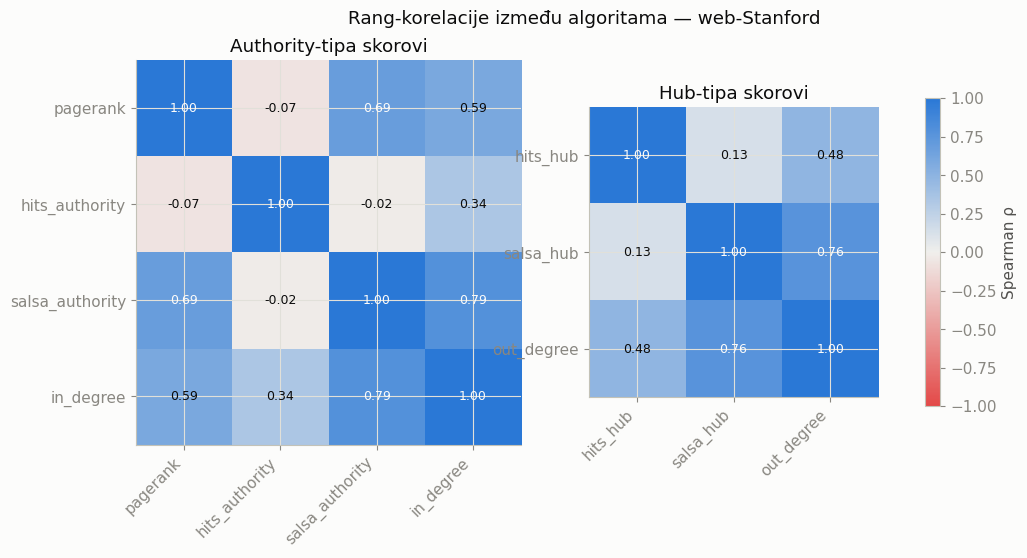

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [4, 3]})

for ax, mat, title in zip(axes, [auth_corr, hub_corr], ["Authority-tipa skorovi", "Hub-tipa skorovi"]):
    im = ax.imshow(mat.values.astype(float), cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(mat)), mat.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(mat)), mat.index)
    for i in range(len(mat)):
        for j in range(len(mat)):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color=INK if abs(val) < 0.6 else "#fcfcfb", fontsize=9)
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.8, label="Spearman ρ")
fig.suptitle("Rang-korelacije između algoritama — web-Stanford")
save_fig(fig, "f5_korelacije.png")
plt.show()

## 2. Preklapanje top-k skupova čvorova

In [4]:
def topk_overlap_table(group, ks=(10, 50, 100, 500, 1000)):
    names = list(group.keys())
    rows = []
    for a, b in itertools.combinations(names, 2):
        row = {"par": f"{a} vs {b}"}
        for k in ks:
            top_a = set(np.argsort(-group[a])[:k])
            top_b = set(np.argsort(-group[b])[:k])
            row[f"k={k}"] = len(top_a & top_b) / k
        rows.append(row)
    return pd.DataFrame(rows).set_index("par")

auth_overlap = topk_overlap_table(AUTH_GROUP)
hub_overlap = topk_overlap_table(HUB_GROUP)

print("Preklapanje top-k (authority-tipa):")
print((auth_overlap * 100).round(1))
print()
print("Preklapanje top-k (hub-tipa):")
print((hub_overlap * 100).round(1))

Preklapanje top-k (authority-tipa):
                                   k=10  k=50  k=100  k=500  k=1000
par                                                                
pagerank vs hits_authority         30.0  20.0   20.0   10.8     7.5
pagerank vs salsa_authority        60.0  68.0   60.0   46.2    42.4
pagerank vs in_degree              40.0  66.0   59.0   43.6    38.9
hits_authority vs salsa_authority  60.0  24.0   18.0   18.0    15.2
hits_authority vs in_degree        90.0  30.0   18.0   18.2    15.2
salsa_authority vs in_degree       70.0  80.0   95.0   93.0    90.6

Preklapanje top-k (hub-tipa):
                         k=10  k=50  k=100  k=500  k=1000
par                                                      
hits_hub vs salsa_hub     0.0   0.0    0.0    0.0     0.0
hits_hub vs out_degree    0.0   0.0    0.0    0.0     0.0
salsa_hub vs out_degree  10.0  38.0   65.0   75.2    77.8


Sačuvano: slike\f5_topk_overlap.png


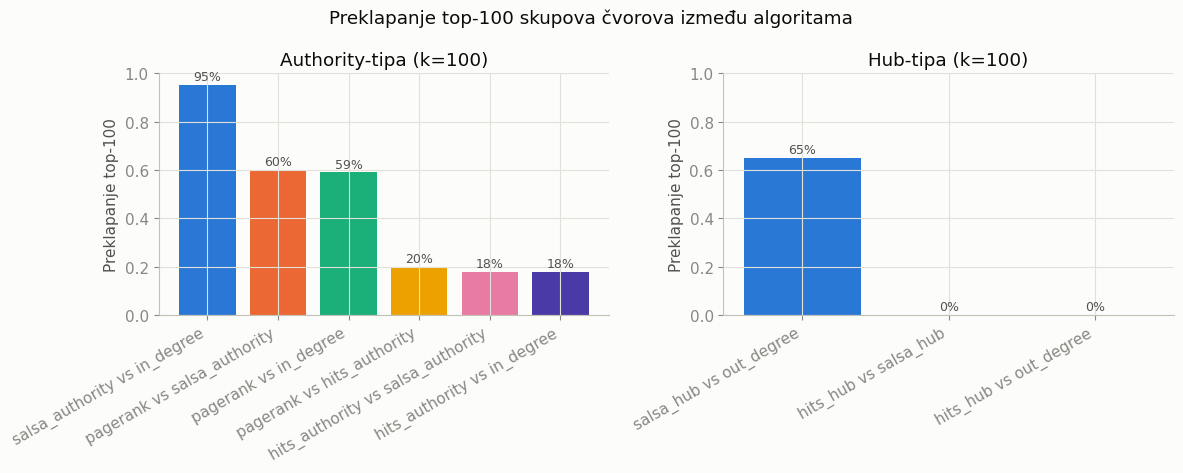

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, overlap, title in zip(axes, [auth_overlap, hub_overlap], ["Authority-tipa (k=100)", "Hub-tipa (k=100)"]):
    vals = overlap["k=100"].sort_values(ascending=False)
    colors = PAIR_COLORS[: len(vals)]
    ax.bar(range(len(vals)), vals.values, color=colors)
    ax.set_xticks(range(len(vals)), vals.index, rotation=30, ha="right")
    ax.set_ylabel("Preklapanje top-100")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=INK_2, fontsize=9)

fig.suptitle("Preklapanje top-100 skupova čvorova između algoritama")
fig.tight_layout()
save_fig(fig, "f5_topk_overlap.png")
plt.show()

## 3. Udeo "ugašenih" (praktično nula) skorova, svi algoritmi

Sačuvano: slike\f5_ugaseni_svi.png


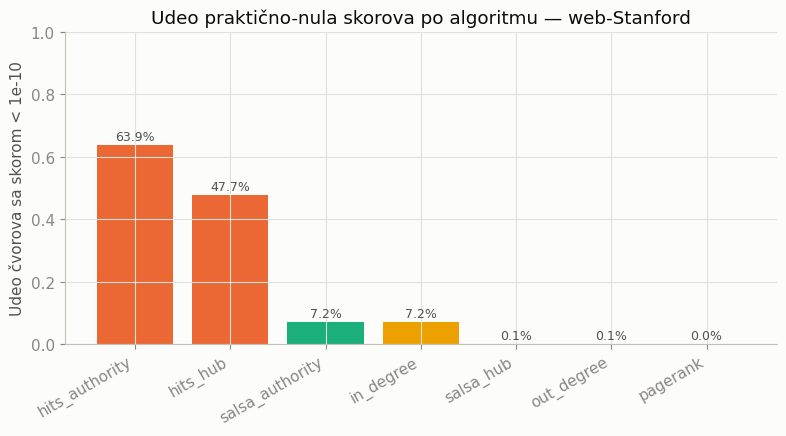

In [6]:
ALL_SCORES = {**AUTH_GROUP, **HUB_GROUP}
negligible_fracs = {name: (arr < 1e-10).sum() / n for name, arr in ALL_SCORES.items()}
negligible_series = pd.Series(negligible_fracs).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [PALETTE["hits"] if "hits" in name else PALETTE["salsa"] if "salsa" in name
          else PALETTE["pagerank"] if name == "pagerank" else PALETTE["baseline"]
          for name in negligible_series.index]
ax.bar(negligible_series.index, negligible_series.values, color=colors)
ax.set_ylabel("Udeo čvorova sa skorom < 1e-10")
ax.set_ylim(0, 1)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(negligible_series.values):
    ax.text(i, v + 0.015, f"{v:.1%}", ha="center", color=INK_2, fontsize=9)
ax.set_title("Udeo praktično-nula skorova po algoritmu — web-Stanford")
fig.tight_layout()
save_fig(fig, "f5_ugaseni_svi.png")
plt.show()

## 4. Test hipoteze H3 — HITS vs. SALSA na istom grafu

**Nalaz iz sekcije 1** je iznenađujući: `pagerank` vs. `hits_authority` ima Spearman ρ = **-0,07** (praktično nula/blago negativno!), a `hits_authority` vs. `salsa_authority` ρ = **-0,02** — dva algoritma koja operišu nad IDENTIČNIM grafom, a njihova rangiranja su međusobno skoro nezavisna. Pre nego što ovo prihvatimo kao nalaz, provaljavamo da li je to artefakt HITS-ovog masovnog "gašenja" skorova (Faza 3: 63,9% authority skorova ≈ 0) — jer korelacija računata nad hiljadama međusobno "vezanih" nula-vrednosti može biti nasumična, bez stvarnog značenja (isti problem kao u validaciji u Fazi 3).

In [7]:
mask_nonzero_hits = hits_authority > 1e-10
mask_nonzero_hits_hub = hits_hub > 1e-10

rho_hs_masked, _ = spearmanr(hits_authority[mask_nonzero_hits], salsa_authority[mask_nonzero_hits])
rho_hp_masked, _ = spearmanr(hits_authority[mask_nonzero_hits], pagerank_scores[mask_nonzero_hits])
rho_hub_masked, _ = spearmanr(hits_hub[mask_nonzero_hits_hub], salsa_hub[mask_nonzero_hits_hub])

print(f"Nenula HITS authority čvorova: {mask_nonzero_hits.sum():,} ({mask_nonzero_hits.sum()/n:.1%})")
print(f"Spearman(hits_authority, salsa_authority) | samo nenula HITS: {rho_hs_masked:.4f}")
print(f"Spearman(hits_authority, pagerank)         | samo nenula HITS: {rho_hp_masked:.4f}")
print(f"Spearman(hits_hub, salsa_hub)               | samo nenula HITS: {rho_hub_masked:.4f}")

Nenula HITS authority čvorova: 101,894 (36.1%)
Spearman(hits_authority, salsa_authority) | samo nenula HITS: 0.1981
Spearman(hits_authority, pagerank)         | samo nenula HITS: -0.1069
Spearman(hits_hub, salsa_hub)               | samo nenula HITS: 0.4108


**H3 je potvrđena — i nije artefakt "gašenja" skorova.** I kada se ograničimo isključivo na čvorove kojima HITS dodeljuje ne-trivijalan (nenula) authority skor, korelacija sa SALSA-om ostaje niska (≈0,20), a sa PageRank-om ostaje **negativna** (≈-0,11). HITS-ovo rangiranje je, čak i među čvorovima koje sam HITS smatra "bitnim", suštinski drugačije od SALSA-inog i PageRank-ovog rangiranja istih čvorova. Ovo je u duhu glavnog nalaza referentnog Najork rada — da HITS i SALSA, uprkos zajedničkom poreklu i istom ulaznom grafu, proizvode kvalitativno različita rangiranja, sa SALSA-om koja je znatno bliža "razumnim" merama (in-degree, PageRank).

## 5. Sažetak rezultata — sve tri hipoteze

In [8]:
summary = pd.DataFrame({
    "Hipoteza": ["H1", "H2", "H3"],
    "Tvrdnja": [
        "SALSA authority ≈ in-degree na jednoj komponenti",
        "HITS 'gasi' čvorove van dominantne komponente više nego SALSA/PageRank",
        "HITS i SALSA daju međusobno slabo korelisana rangiranja",
    ],
    "Status": ["Potvrđena (nijansirano)", "Potvrđena", "Potvrđena"],
    "Ključna brojka": [
        f"ρ(SALSA-aut, in-deg) = {auth_corr.loc['salsa_authority','in_degree']:.2f} (egzaktno na 1 komponenti)",
        f"HITS: {negligible_series['hits_authority']:.0%} ugašeno vs. SALSA: {negligible_series['salsa_authority']:.0%}, PageRank: {negligible_series['pagerank']:.0%}",
        f"ρ(HITS-aut, SALSA-aut) = {auth_corr.loc['hits_authority','salsa_authority']:.2f}, ρ(HITS-aut, PageRank) = {auth_corr.loc['hits_authority','pagerank']:.2f}",
    ],
})
summary

,Hipoteza,Tvrdnja,Status,Ključna brojka
0,H1,SALSA authority ≈ in-degree na jednoj komponenti,Potvrđena (nijansirano),"ρ(SALSA-aut, in-deg) = 0.79 (egzaktno na 1 kom..."
1,H2,HITS 'gasi' čvorove van dominantne komponente ...,Potvrđena,"HITS: 64% ugašeno vs. SALSA: 7%, PageRank: 0%"
2,H3,HITS i SALSA daju međusobno slabo korelisana r...,Potvrđena,"ρ(HITS-aut, SALSA-aut) = -0.02, ρ(HITS-aut, Pa..."


## Zaključci — Faza 5 (i sinteza celog projekta)

**Glavni nalaz: SALSA je "razumniji" link-based signal, HITS je iznenađujuće izolovan.** Matrica korelacija (`f5_korelacije.png`) pokazuje jasan obrazac: PageRank, SALSA-authority i in-degree međusobno koreliraju umereno-do-jako (ρ = 0,59–0,79) — sva tri "slažu se" oko toga koji su čvorovi bitni. **HITS je odvojen od te tri mere** (ρ = -0,07 do 0,34), uključujući skoro-nultu korelaciju sa SALSA-om (ρ = -0,02) koja operiše nad **istim** grafom. Ovaj nalaz je robustan — ostaje suštinski isti (ρ ≈ -0,11 sa PageRank-om, ρ ≈ 0,20 sa SALSA-om) i kada se iz poređenja isključe HITS-ovi "ugašeni" (≈0) čvorovi, dakle nije artefakt masovnog gašenja skorova iz Faze 3.

**Hub strana je još drastičnija.** `hits_hub` i `salsa_hub` imaju **0% preklapanja u top-1000** (tabela u sekciji 2) — i `hits_hub` sa sirovim `out_degree` takođe 0%. Zajedno sa Fazom 3 nalazom da su top HITS hub skorovi skoro identični (razlika u 5.-6. decimali) i da postoji samo ~77 razlučivih vrednosti među 2000 najboljih — ovo je konkretna, merljiva slika **TKC efekta** [3]: HITS-ova mutual-reinforcement iteracija je "zaključala" jednu gusto međusobno povezanu grupu čvorova sa umerenim (ne ekstremnim) izlaznim stepenom, potpuno odvojenu od čvorova koje bilo SALSA bilo prost broj izlaznih linkova smatraju dobrim hub-ovima.

**Sve tri hipoteze iz README-a su potvrđene:**
- **H1** (nijansirano) — SALSA authority je egzaktno proporcionalan in-degree-u na jednoj komponenti (Faza 4, validacija), i snažno (ρ=0,79) ali ne savršeno korelisan na stvarnom, fragmentisanom grafu.
- **H2** — HITS "gasi" (skor < 10⁻¹⁰) **64%** authority i **48%** hub skorova, naspram SALSA-e (7% / 0,1%) i PageRank-a (0%) — direktna posledica power-iteracije ka jednom dominantnom pravcu (Faza 3).
- **H3** — HITS i SALSA, uprkos identičnom ulaznom grafu, daju rangiranja koja su međusobno skoro nekorelisana (authority ρ=-0,02, hub top-1000 preklapanje 0%).

**Veza sa referentnim Najork radom.** Rad [5] je na osnovu 28.043 upita i ljudskih relevance labela pokazao da SALSA "kao izolovana karakteristika" bitno nadmašuje HITS (Slika 2 u radu: `salsa-aut-*` grupisano visoko, `hits-aut-*` znatno niže). Mi nemamo relevance labele, pa ne možemo direktno reprodukovati MAP/NDCG/MRR — ali naš nalaz (SALSA visoko korelisana sa PageRank-om/in-degree-om, koji su razumne mere kvaliteta; HITS suštinski nekorelisan sa bilo čim od toga) je **konzistentan i komplementaran** sa njihovim: nezavisno od toga da li HITS-ovo rangiranje poboljšava kvalitet pretrage, ono se sistemski razlikuje od svih drugih razmatranih mera, na način koji se uklapa u poznatu TKC kritiku HITS-a [3].

**Status core faza projekta:** `01`-`05` su završene i validirane. Sledeći (i poslednji) korak je `07_demo.ipynb` — sažeta demonstraciona sveska za odbranu projekta, koja rekapitulira ključne nalaze i grafike bez ponovnog izvršavanja svih skupih računanja.
